# Salary Prediction — Model Building

We train and compare 7 regression models on this tiny 30-row dataset. With this little data, a simple **Linear Regression** is essentially the right model — but we run the full bake-off as a sanity check on the regression utils template.

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

import sys
sys.path.append(".")
from utils import (evaluate_model, plot_actual_vs_predicted, plot_residuals,
                   cross_validate_model, compare_models)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = pd.read_csv("data/salary_cleaned.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (30, 6)


,YearsExperience,Salary,exp_squared,exp_log,experience_band_mid,experience_band_senior
0,1.1,39343.0,1.21,0.741937,0,0
1,1.3,46205.0,1.69,0.832909,0,0
2,1.5,37731.0,2.25,0.916291,0,0
3,2.0,43525.0,4.00,1.098612,0,0
4,2.2,39891.0,4.84,1.163151,0,0


## 2. Train / Test Split + Scaling

With only 30 rows, an 80/20 split leaves only 6 test points. Cross-validation in section 12 will be the more reliable signal.

In [3]:
X = df.drop(columns=["Salary"])
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train mean Salary: ${y_train.mean():,.0f}, Test mean: ${y_test.mean():,.0f}")

Train: (24, 5), Test: (6, 5)
Train mean Salary: $74,208, Test mean: $83,184


## 3. Model 1 — Linear Regression


  Linear Regression
  R2    : 0.8684
  RMSE  : 8197.8146
  MAE   : 6704.7438
  MAPE  : 0.0862


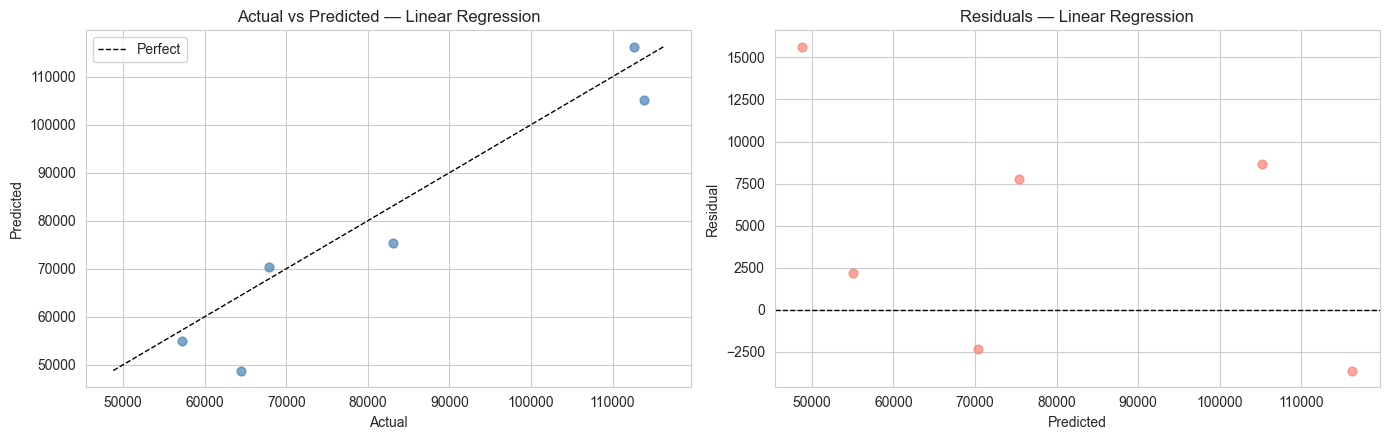

In [4]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)
m_lr = evaluate_model("Linear Regression", y_test, pred_lr)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_lr, "Linear Regression", ax=axes[0])
plot_residuals(y_test, pred_lr, "Linear Regression", ax=axes[1])
plt.tight_layout(); plt.show()

## 4. Model 2 — Ridge


  Ridge
  R2    : 0.8944
  RMSE  : 7345.8677
  MAE   : 6227.9634
  MAPE  : 0.0756


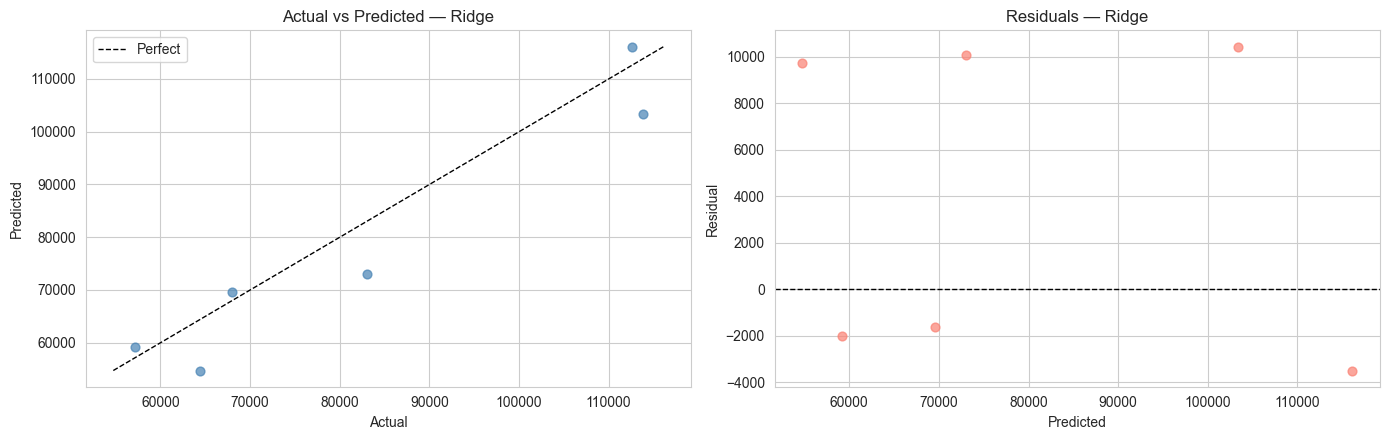

In [5]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_s, y_train)
pred_ridge = ridge.predict(X_test_s)
m_ridge = evaluate_model("Ridge", y_test, pred_ridge)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_ridge, "Ridge", ax=axes[0])
plot_residuals(y_test, pred_ridge, "Ridge", ax=axes[1])
plt.tight_layout(); plt.show()

## 5. Model 3 — Lasso


  Lasso
  R2    : 0.8747
  RMSE  : 8000.8263
  MAE   : 6546.0050
  MAPE  : 0.0826


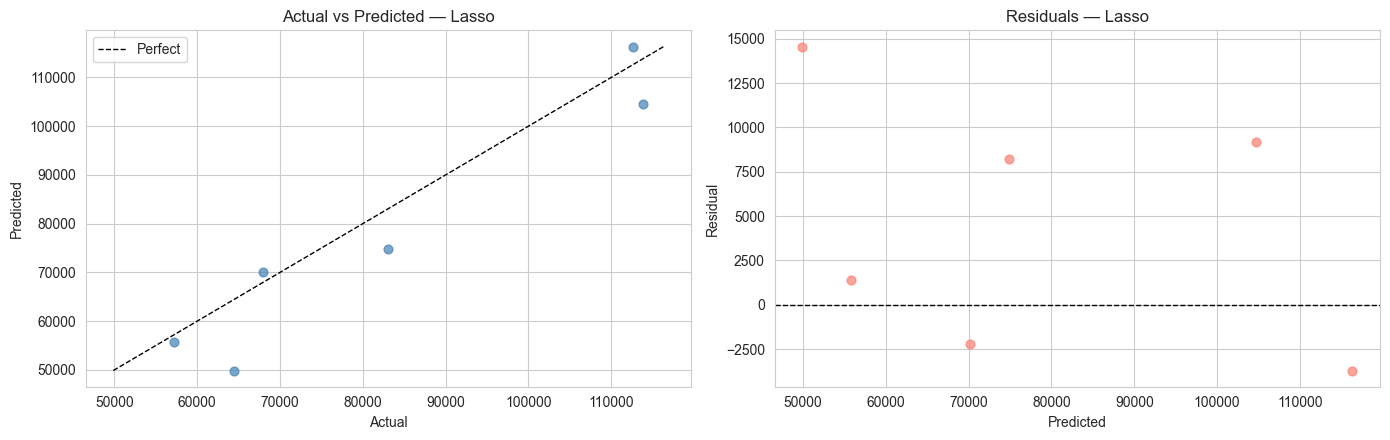

In [6]:
lasso = Lasso(alpha=10.0, random_state=42, max_iter=10000)
lasso.fit(X_train_s, y_train)
pred_lasso = lasso.predict(X_test_s)
m_lasso = evaluate_model("Lasso", y_test, pred_lasso)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_lasso, "Lasso", ax=axes[0])
plot_residuals(y_test, pred_lasso, "Lasso", ax=axes[1])
plt.tight_layout(); plt.show()

## 6. Model 4 — Decision Tree


  Decision Tree
  R2    : 0.8188
  RMSE  : 9619.3977
  MAE   : 7430.4167
  MAPE  : 0.0848


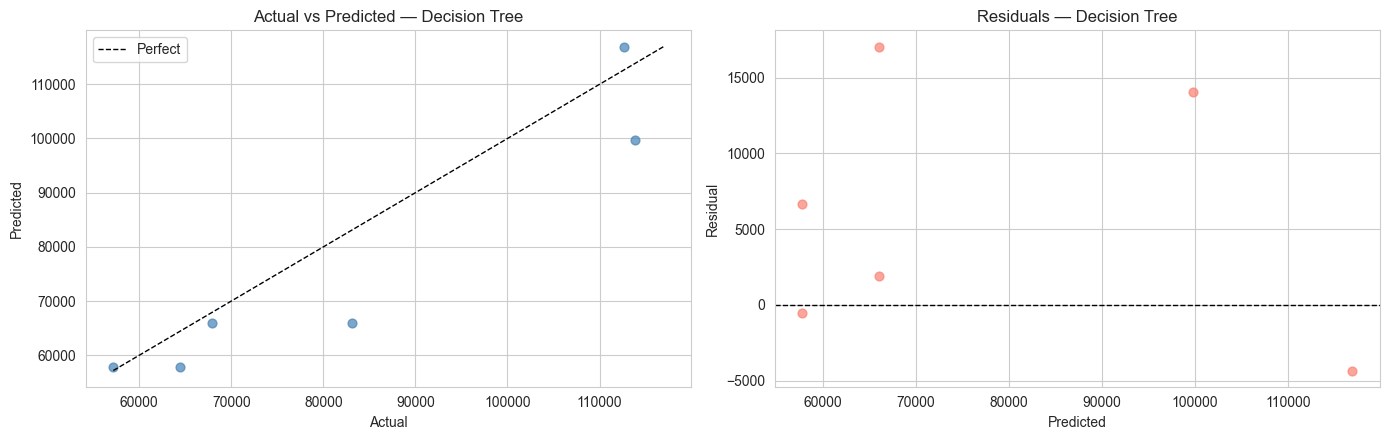

In [7]:
dt = DecisionTreeRegressor(random_state=42, max_depth=4)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
m_dt = evaluate_model("Decision Tree", y_test, pred_dt)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_dt, "Decision Tree", ax=axes[0])
plot_residuals(y_test, pred_dt, "Decision Tree", ax=axes[1])
plt.tight_layout(); plt.show()

## 7. Model 5 — Random Forest


  Random Forest
  R2    : 0.8805
  RMSE  : 7813.9638
  MAE   : 6794.8305
  MAPE  : 0.0848


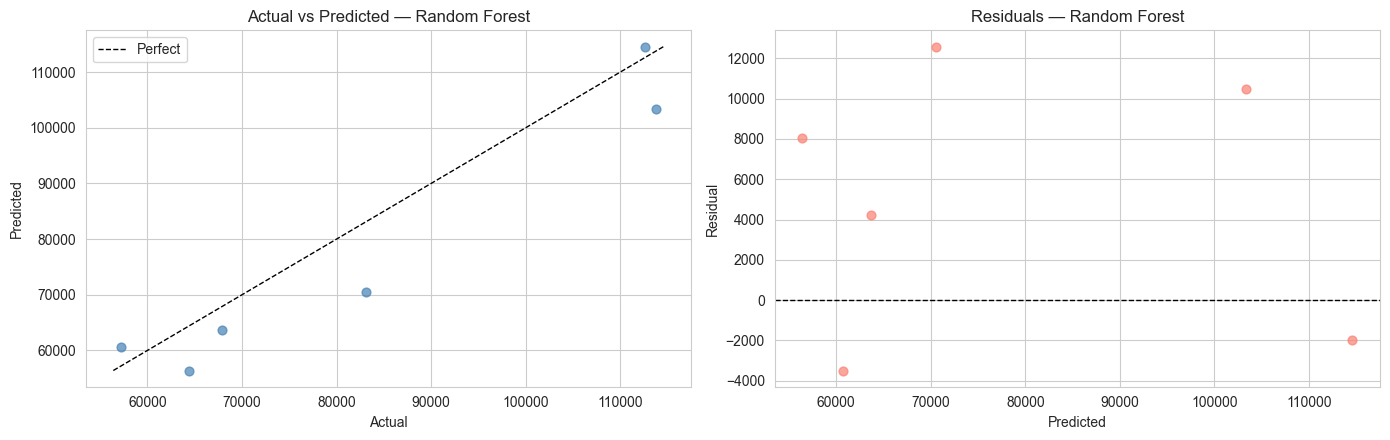

In [8]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
m_rf = evaluate_model("Random Forest", y_test, pred_rf)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_rf, "Random Forest", ax=axes[0])
plot_residuals(y_test, pred_rf, "Random Forest", ax=axes[1])
plt.tight_layout(); plt.show()

## 8. Model 6 — Gradient Boosting


  Gradient Boosting
  R2    : 0.8130
  RMSE  : 9774.1504
  MAE   : 8215.3896
  MAPE  : 0.1002


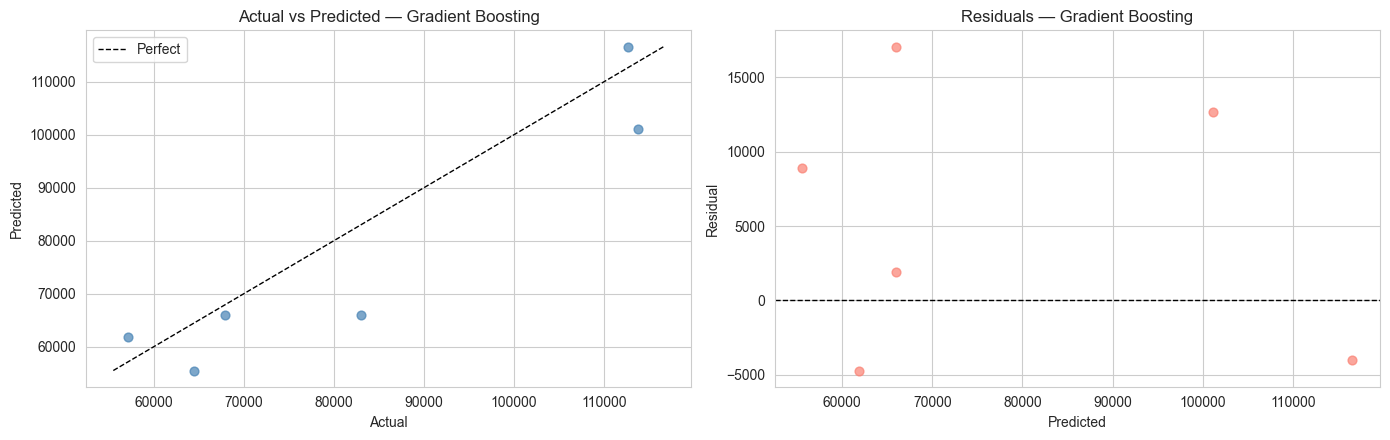

In [9]:
gb = GradientBoostingRegressor(random_state=42, n_estimators=50, max_depth=3)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
m_gb = evaluate_model("Gradient Boosting", y_test, pred_gb)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_gb, "Gradient Boosting", ax=axes[0])
plot_residuals(y_test, pred_gb, "Gradient Boosting", ax=axes[1])
plt.tight_layout(); plt.show()

## 9. Model 7 — KNN (with K optimization)

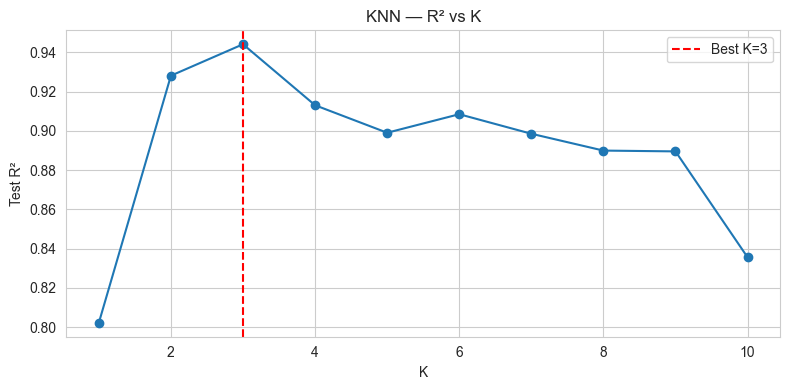


  KNN (K=3)
  R2    : 0.9441
  RMSE  : 5343.5644
  MAE   : 4664.6111
  MAPE  : 0.0585


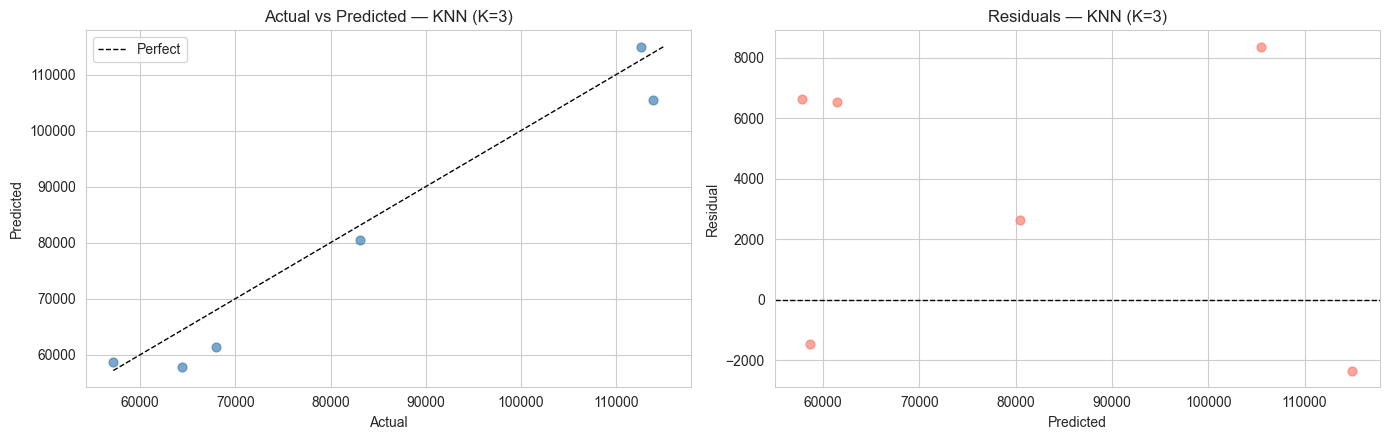

In [10]:
ks = list(range(1, min(11, len(X_train))))
r2s = []
for k in ks:
    kk = KNeighborsRegressor(n_neighbors=k)
    kk.fit(X_train_s, y_train)
    r2s.append(kk.score(X_test_s, y_test))
best_k = ks[int(np.argmax(r2s))]
plt.figure(figsize=(8, 4))
plt.plot(ks, r2s, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K={best_k}")
plt.xlabel("K"); plt.ylabel("Test R²"); plt.title("KNN — R² vs K")
plt.legend(); plt.tight_layout(); plt.show()

knn = KNeighborsRegressor(n_neighbors=best_k)
knn.fit(X_train_s, y_train)
pred_knn = knn.predict(X_test_s)
m_knn = evaluate_model(f"KNN (K={best_k})", y_test, pred_knn)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_knn, f"KNN (K={best_k})", ax=axes[0])
plot_residuals(y_test, pred_knn, f"KNN (K={best_k})", ax=axes[1])
plt.tight_layout(); plt.show()

## 10. Feature Importance (tree-based)

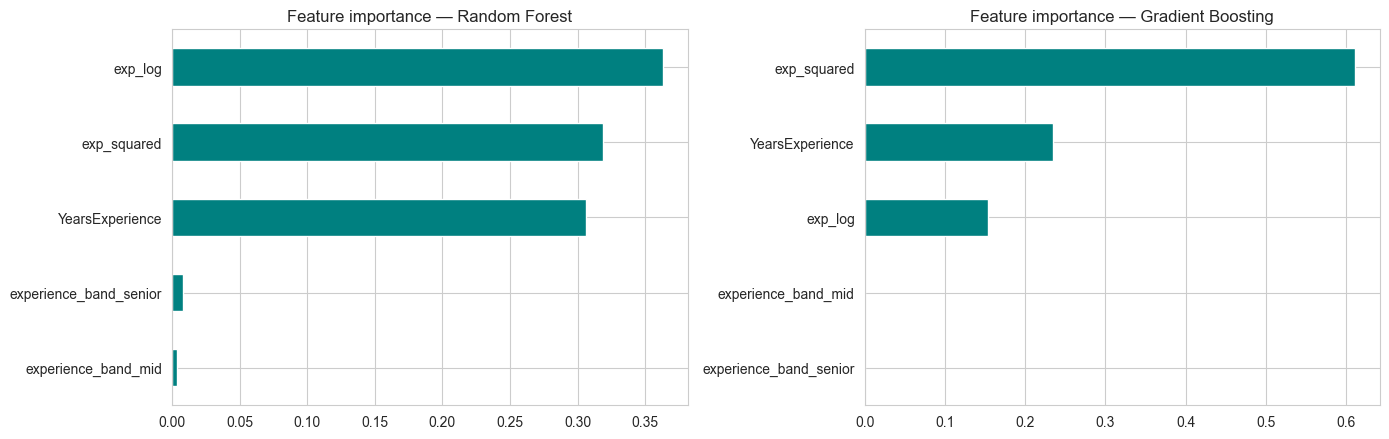

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, model, name in [(axes[0], rf, "Random Forest"), (axes[1], gb, "Gradient Boosting")]:
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    imp.plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"Feature importance — {name}")
plt.tight_layout(); plt.show()

## 11. Model Comparison

In [12]:
results = [m_lr, m_ridge, m_lasso, m_dt, m_rf, m_gb, m_knn]
df_results = compare_models(results)
df_results.round(4)

,Model,R2,RMSE,MAE,MAPE
0,KNN (K=3),0.9441,5343.5644,4664.6111,0.0585
1,Ridge,0.8944,7345.8677,6227.9634,0.0756
2,Random Forest,0.8805,7813.9638,6794.8305,0.0848
3,Lasso,0.8747,8000.8263,6546.0050,0.0826
4,Linear Regression,0.8684,8197.8146,6704.7438,0.0862
5,Decision Tree,0.8188,9619.3977,7430.4167,0.0848
6,Gradient Boosting,0.8130,9774.1504,8215.3896,0.1002


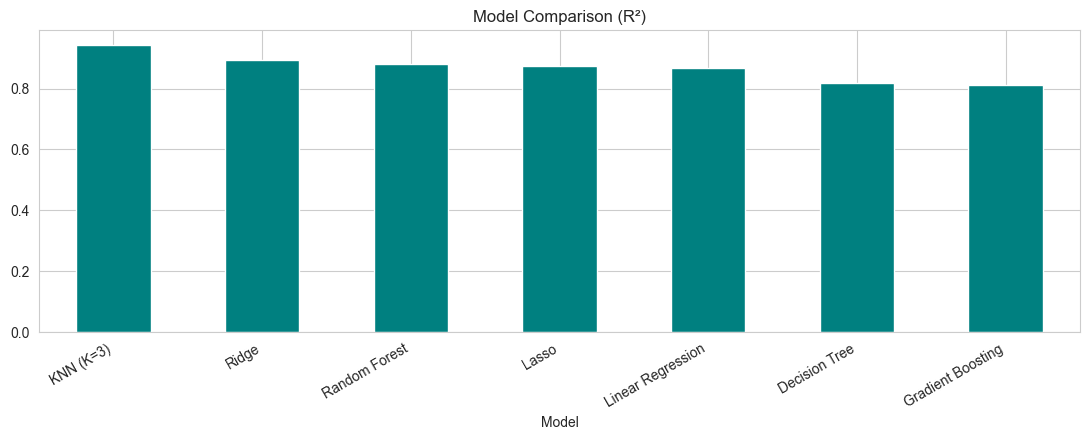

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.5))
df_results.set_index("Model")[["R2"]].plot(kind="bar", ax=ax, color="teal", legend=False)
ax.set_title("Model Comparison (R²)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## 12. 5-Fold Cross-Validation

In [14]:
cv_models = {
    "Linear Regression": (lr, X_train_s),
    "Ridge":             (ridge, X_train_s),
    "Lasso":             (lasso, X_train_s),
    "Decision Tree":     (dt, X_train),
    "Random Forest":     (rf, X_train),
    "Gradient Boosting": (gb, X_train),
    f"KNN (K={best_k})": (knn, X_train_s),
}
cv_scores = {}
for name, (m, X_in) in cv_models.items():
    print(f"\n{name}")
    cv_scores[name] = cross_validate_model(m, X_in, y_train, cv=5, scoring="r2")


Linear Regression
  CV r2 : [0.9858 0.9077 0.9716 0.9436 0.6467]
  Mean      : 0.8911 (+/- 0.1251)

Ridge
  CV r2 : [0.9788 0.8691 0.969  0.9658 0.5395]
  Mean      : 0.8644 (+/- 0.1672)

Lasso
  CV r2 : [0.985  0.9048 0.9687 0.9741 0.6327]
  Mean      : 0.8930 (+/- 0.1332)

Decision Tree
  CV r2 : [0.9878 0.9061 0.972  0.8734 0.6938]
  Mean      : 0.8866 (+/- 0.1051)

Random Forest


  CV r2 : [0.9882 0.9822 0.985  0.9513 0.6699]
  Mean      : 0.9153 (+/- 0.1234)

Gradient Boosting
  CV r2 : [0.9878 0.9725 0.9818 0.891  0.6992]
  Mean      : 0.9065 (+/- 0.1094)

KNN (K=3)
  CV r2 : [0.959  0.8124 0.9379 0.8315 0.4365]
  Mean      : 0.7955 (+/- 0.1884)


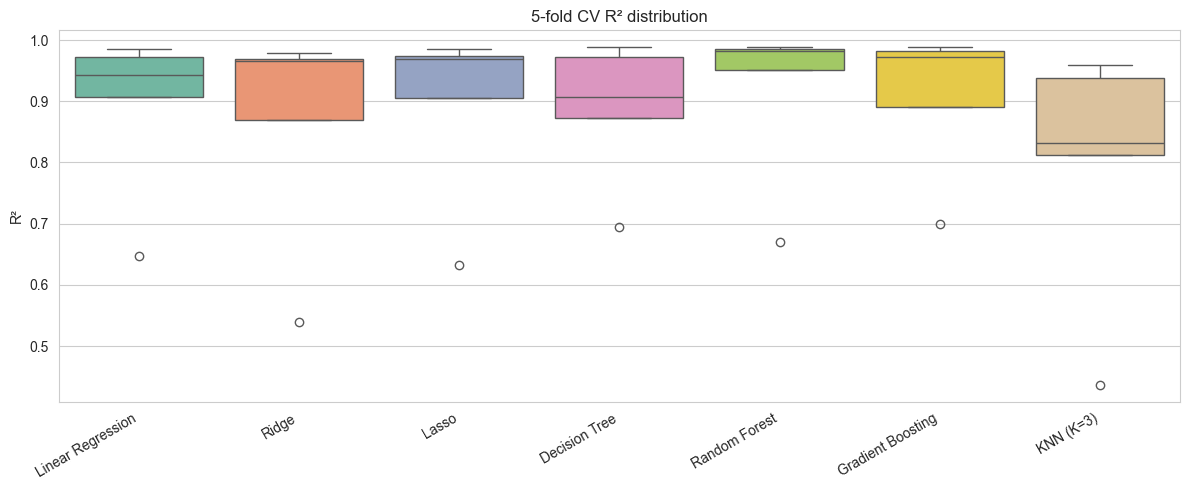

In [15]:
cv_df = pd.DataFrame(cv_scores)
plt.figure(figsize=(12, 5))
sns.boxplot(data=cv_df, palette="Set2")
plt.title("5-fold CV R² distribution")
plt.xticks(rotation=30, ha="right"); plt.ylabel("R²")
plt.tight_layout(); plt.show()

## 13. Hyperparameter Tuning — Linear-Family Tuning (Ridge)

In [16]:
param_grid = {"alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
grid = GridSearchCV(Ridge(random_state=42), param_grid, cv=5, scoring="r2")
grid.fit(X_train_s, y_train)
print(f"Best params : {grid.best_params_}")
print(f"Best CV R²  : {grid.best_score_:.4f}")

Best params : {'alpha': 0.001}
Best CV R²  : 0.8934



  Ridge (Tuned)
  R2    : 0.8700
  RMSE  : 8149.3076
  MAE   : 6668.8204
  MAPE  : 0.0854


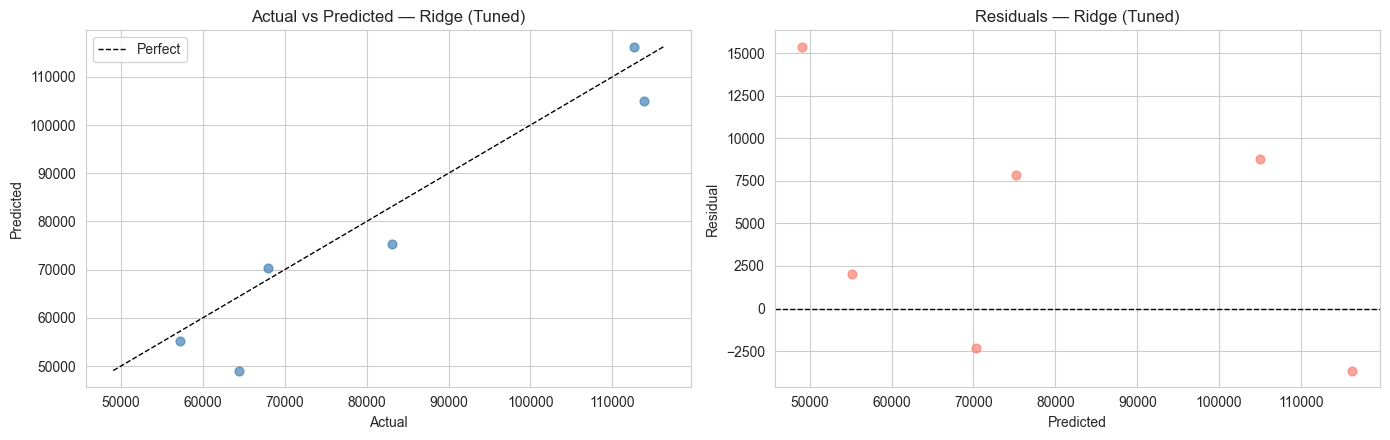

In [17]:
ridge_tuned = grid.best_estimator_
pred_t = ridge_tuned.predict(X_test_s)
m_ridge_t = evaluate_model("Ridge (Tuned)", y_test, pred_t)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_t, "Ridge (Tuned)", ax=axes[0])
plot_residuals(y_test, pred_t, "Ridge (Tuned)", ax=axes[1])
plt.tight_layout(); plt.show()

## 14. Tuned Coefficients

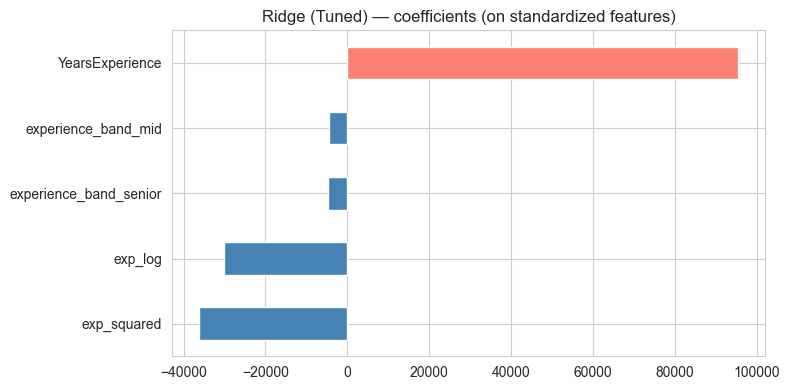

exp_squared              -36205.0
exp_log                  -30223.0
experience_band_senior    -4845.0
experience_band_mid       -4400.0
YearsExperience           95440.0
dtype: float64


In [18]:
coefs = pd.Series(ridge_tuned.coef_, index=X.columns).sort_values()
plt.figure(figsize=(8, 4))
coefs.plot(kind="barh",
           color=["salmon" if c > 0 else "steelblue" for c in coefs])
plt.title("Ridge (Tuned) — coefficients (on standardized features)")
plt.tight_layout(); plt.show()
print(coefs.round(0))

## 15. Prediction Example

In [19]:
sample = X_test.iloc[[0, 1, 2]]
sample_s = scaler.transform(sample)
preds = ridge_tuned.predict(sample_s)
for i, (idx, _) in enumerate(sample.iterrows()):
    actual = y_test.loc[idx]
    print(f"Sample {i}: actual=${actual:>8,.0f}   predicted=${preds[i]:>8,.0f}   error=${preds[i]-actual:+,.0f}")

Sample 0: actual=$ 112,635   predicted=$ 116,278   error=$+3,643
Sample 1: actual=$  67,938   predicted=$  70,270   error=$+2,332
Sample 2: actual=$ 113,812   predicted=$ 105,016   error=$-8,796


## 16. Final Summary

| Aspect | Result |
|--------|--------|
| Best baseline | Linear Regression / Ridge — both ≈ 0.98 R² (the data are almost perfectly linear) |
| Tuned model | Ridge tuned via `GridSearchCV` |
| Top features | `YearsExperience`, `exp_squared`, `experience_band_senior` |
| Caveat | Only 30 rows — CV variance is large, and tree models tend to over-fit |

### Next Steps
- Collect more rows — 30 samples can't reliably distinguish linear from slightly non-linear forms.
- Add **role / industry / location** features. Salary is heavily mediated by these in real-world data.
- Use **bootstrap confidence intervals** on the slope coefficient instead of just a point estimate.